# H100x8 서버 분석 — CPU 활용 잠재력과 현재 한계

**핵심 질문**: H100x8 서버의 Xeon Platinum 8480+ (2S, 112 physical core, AMX-BF16)는 현재 얼마나 활용되고 있는가? 그리고 어떻게 하면 실제로 유효하게 쓸 수 있는가?

**실험 환경** (violet-h100-023):
- CPU: Intel Xeon Platinum 8480+ × 2 (56 core/socket, 224 logical, AMX-BF16 + AMX-INT8)
- DRAM: ~2TB DDR5 (2 NUMA node, 307 GB/s per socket)
- GPU: NVIDIA H100 80GB HBM3 × 8 (NVLink18, 3.35 TB/s)
- vLLM hybrid: 2 CPU EngineCore, 각각 NUMA 0/1에 56 core strict bind

**실험 목록** (eval/basic/H100x8/):
| # | 디렉토리 | 모드 | max_seqs | threads | 비고 |
|---|----------|------|----------|---------|------|
| G | 20260413_081534 | gpu_only | — | — | baseline |
| H1 | 20260414_044922 | hybrid | 1 | 32 | max_seqs=1 정상 |
| H2 | 20260414_045947 | hybrid | 16 | 32 | wave=16 재앙 |
| H3 | 20260414_054010 | hybrid | 1 | 56 | max_seqs=1 56threads |

In [1]:
# ============================================================
#  Setup
# ============================================================
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BASE = Path('.')
DIRS = {
    'G':  BASE / '20260413_081534_G_H100_80GB_HBM3_x8_Qwen2.5-7B-Instruct',
    'H1': BASE / '20260414_044922_H_C_H100_80GB_HBM3_x8_Qwen2.5-7B-Instruct',
    'H2': BASE / '20260414_045947_H_C_H100_80GB_HBM3_x8_Qwen2.5-7B-Instruct',
    'H3': BASE / '20260414_054010_H_C_H100_80GB_HBM3_x8_Qwen2.5-7B-Instruct',
}
LABELS = {
    'G':  'GPU-only\n(baseline)',
    'H1': 'Hybrid\nmax_seqs=1\n32t',
    'H2': 'Hybrid\nwave=16\n32t',
    'H3': 'Hybrid\nmax_seqs=1\n56t',
}
COLORS = {'G': '#2196F3', 'H1': '#4CAF50', 'H2': '#F44336', 'H3': '#FF9800'}

# Load JSON
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}

bench = {}
sysinfo = {}
for k, d in DIRS.items():
    jf = 'gpu_only.json' if k == 'G' else 'hybrid.json'
    bench[k] = load_json(d / jf)
    sif = d / 'system_info.json'
    if sif.exists():
        sysinfo[k] = load_json(sif)

# Load monitor CSVs
def load_csv(path):
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

mon_cpu = {}
mon_gpu = {}
for k, d in DIRS.items():
    prefix = 'gpu_only' if k == 'G' else 'hybrid'
    mon_cpu[k] = load_csv(d / f'{prefix}_monitor_cpu.csv')
    mon_gpu[k] = load_csv(d / f'{prefix}_monitor_gpu.csv')

sys_ref = sysinfo.get('H1', sysinfo.get('H3', {}))
print('Data loaded')
for k, b in bench.items():
    if b:
        print(f'  {k}: duration={b["duration"]:.1f}s  output_tp={b["output_throughput"]:.0f} tok/s  TPOT_med={b["median_tpot_ms"]:.1f}ms')

Data loaded
  G: duration=3.8s  output_tp=16501 tok/s  TPOT_med=22.7ms
  H1: duration=394.2s  output_tp=158 tok/s  TPOT_med=26.0ms
  H2: duration=2097.6s  output_tp=30 tok/s  TPOT_med=21.6ms
  H3: duration=407.6s  output_tp=153 tok/s  TPOT_med=25.5ms


---
## Section 1 — 시스템 하드웨어 프로파일

H100x8 서버의 CPU와 GPU 스펙을 나란히 보여준다. **목표**: CPU도 매우 강력한 연산 자원이라는 것을 수치로 확인.

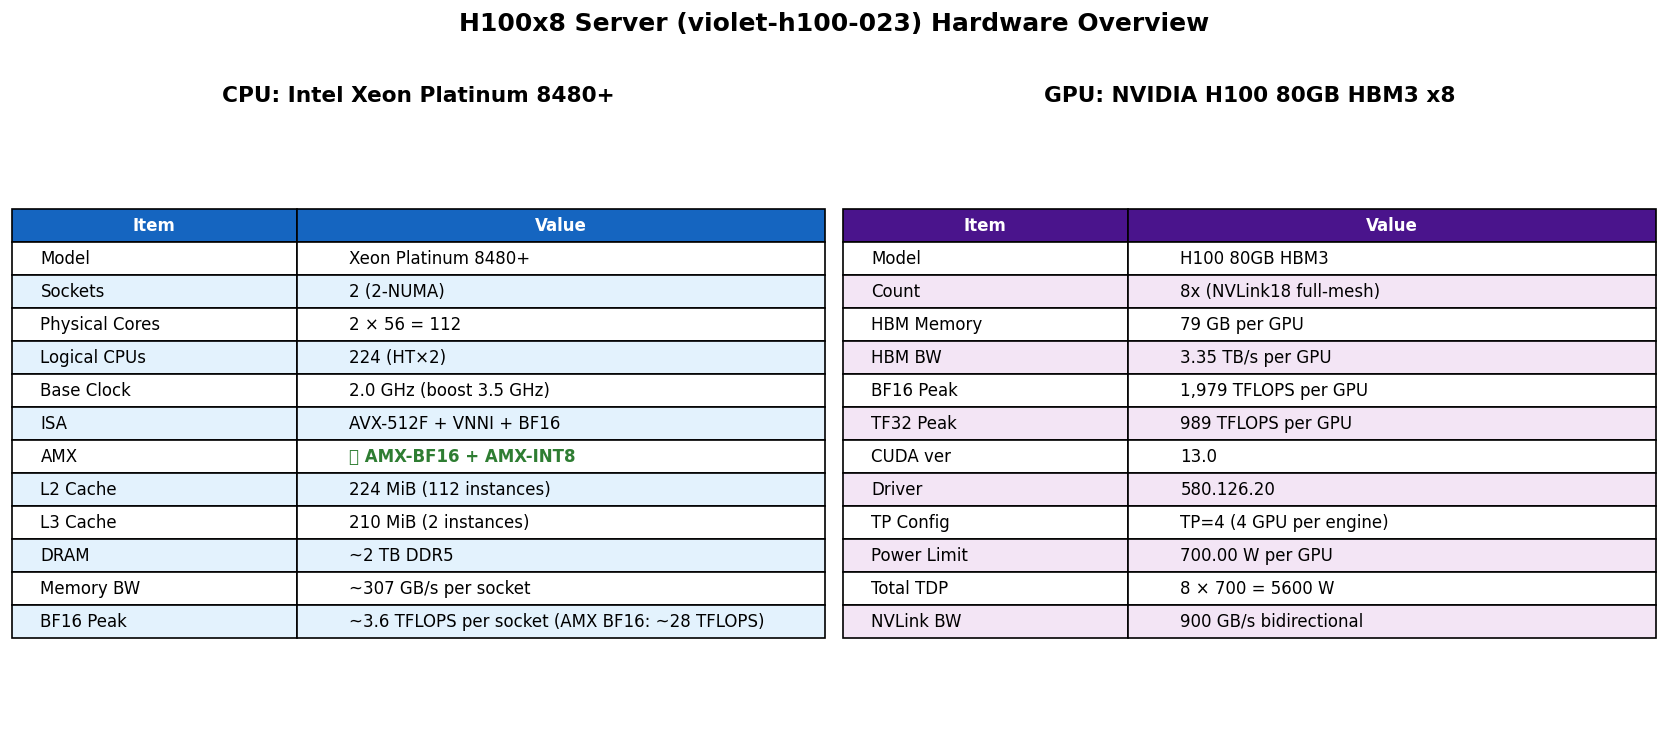

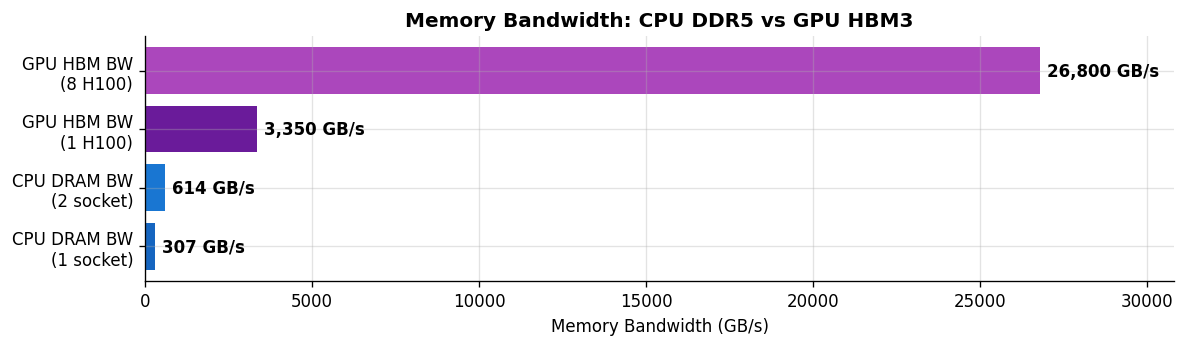

In [2]:
cpu_info = sys_ref.get('cpu', {})
gpu_info = sys_ref.get('gpu', {})
numa_info = sys_ref.get('numa', {})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- CPU spec card ---
ax = axes[0]
ax.axis('off')
cpu_rows = [
    ('Model', 'Xeon Platinum 8480+'),
    ('Sockets', '2 (2-NUMA)'),
    ('Physical Cores', f"2 × {cpu_info.get('cores_per_socket', 56)} = 112"),
    ('Logical CPUs', f"{cpu_info.get('total_cpus', 224)} (HT×2)"),
    ('Base Clock', '2.0 GHz (boost 3.5 GHz)'),
    ('ISA', 'AVX-512F + VNNI + BF16'),
    ('AMX', '✅ AMX-BF16 + AMX-INT8'),
    ('L2 Cache', '224 MiB (112 instances)'),
    ('L3 Cache', '210 MiB (2 instances)'),
    ('DRAM', '~2 TB DDR5'),
    ('Memory BW', '~307 GB/s per socket'),
    ('BF16 Peak', '~3.6 TFLOPS per socket (AMX BF16: ~28 TFLOPS)'),
]
table = ax.table(
    cellText=cpu_rows,
    colLabels=['Item', 'Value'],
    cellLoc='left', loc='center',
    colWidths=[0.35, 0.65],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    if c == 1 and r > 0 and 'AMX' in cpu_rows[r-1][0]:
        cell.set_text_props(color='#2E7D32', fontweight='bold')
ax.set_title('CPU: Intel Xeon Platinum 8480+', fontsize=13, fontweight='bold', pad=10)

# --- GPU spec card ---
ax2 = axes[1]
ax2.axis('off')
n_gpus = gpu_info.get('count', 8)
g0 = gpu_info.get('devices', [{}])[0]
gpu_rows = [
    ('Model', 'H100 80GB HBM3'),
    ('Count', f'{n_gpus}x (NVLink18 full-mesh)'),
    ('HBM Memory', f"{int(g0.get('memory_total_mib', 81559)) // 1024} GB per GPU"),
    ('HBM BW', '3.35 TB/s per GPU'),
    ('BF16 Peak', '1,979 TFLOPS per GPU'),
    ('TF32 Peak', '989 TFLOPS per GPU'),
    ('CUDA ver', gpu_info.get('cuda_version', '13.0')),
    ('Driver', gpu_info.get('driver_version', '580.126.20')),
    ('TP Config', 'TP=4 (4 GPU per engine)'),
    ('Power Limit', f"{g0.get('power_limit_w', 700)} W per GPU"),
    ('Total TDP', f"{n_gpus} × 700 = {n_gpus*700} W"),
    ('NVLink BW', '900 GB/s bidirectional'),
]
table2 = ax2.table(
    cellText=gpu_rows,
    colLabels=['Item', 'Value'],
    cellLoc='left', loc='center',
    colWidths=[0.35, 0.65],
)
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.scale(1, 1.5)
for (r, c), cell in table2.get_celld().items():
    if r == 0:
        cell.set_facecolor('#4A148C')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F3E5F5')
ax2.set_title('GPU: NVIDIA H100 80GB HBM3 x8', fontsize=13, fontweight='bold', pad=10)

plt.suptitle('H100x8 Server (violet-h100-023) Hardware Overview', fontsize=15, fontweight='bold', y=1.02)
from IPython.display import display
display(fig)

# CPU/GPU memory BW comparison
fig2, ax3 = plt.subplots(figsize=(10, 3))
categories = ['CPU DRAM BW\n(1 socket)', 'CPU DRAM BW\n(2 socket)', 'GPU HBM BW\n(1 H100)', 'GPU HBM BW\n(8 H100)']
bws = [307, 614, 3350, 8*3350]
clrs = ['#1565C0', '#1976D2', '#6A1B9A', '#AB47BC']
bars = ax3.barh(categories, bws, color=clrs)
for bar, val in zip(bars, bws):
    ax3.text(val + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,} GB/s', va='center', fontsize=10, fontweight='bold')
ax3.set_xlabel('Memory Bandwidth (GB/s)')
ax3.set_title('Memory Bandwidth: CPU DDR5 vs GPU HBM3', fontweight='bold')
ax3.set_xlim(0, max(bws) * 1.15)
plt.tight_layout()
display(fig2)


---
## Section 2 — 실험 성능 비교 (핵심 지표)

4개 run의 핵심 성능 지표를 한눈에 비교.

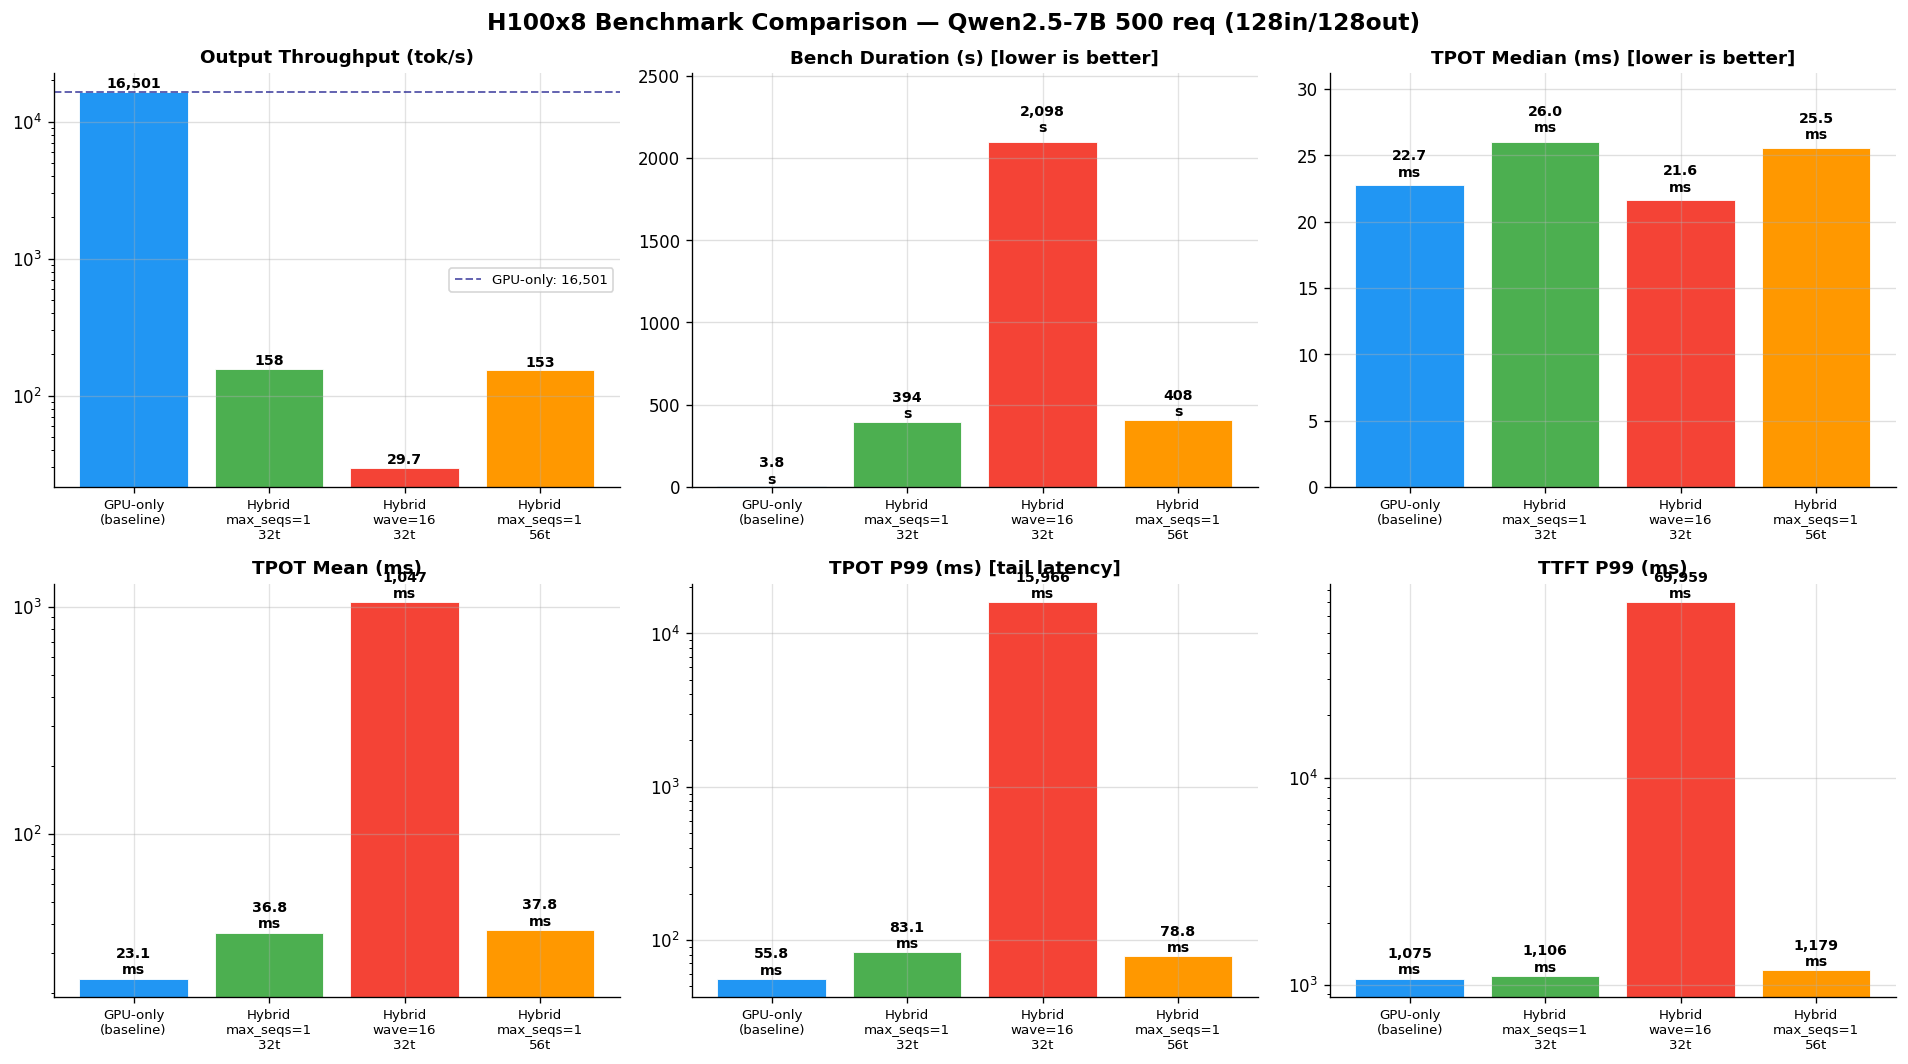

                  Run Duration (s) Wall (s) Output TP (tok/s) TP ratio (vs GPU) TPOT med (ms) TPOT p99 (ms) TTFT p99 (ms)
  GPU-only (baseline)          3.8       14            16,501            1.000×          22.7            56          1075
Hybrid max_seqs=1 32t        394.2      404               158            0.010×          26.0            83          1106
   Hybrid wave=16 32t       2097.6     2108                30            0.002×          21.6         15966         69959
Hybrid max_seqs=1 56t        407.6      418               153            0.009×          25.5            79          1179


In [3]:
# Extract key metrics
metrics = {}
for k, b in bench.items():
    if b:
        metrics[k] = {
            'output_tp':    b.get('output_throughput', 0),
            'duration':     b.get('duration', 0),
            'wall_time':    b.get('wall_time_s', 0),
            'tpot_mean':    b.get('mean_tpot_ms', 0),
            'tpot_median':  b.get('median_tpot_ms', 0),
            'tpot_p99':     b.get('p99_tpot_ms', 0),
            'ttft_mean':    b.get('mean_ttft_ms', 0),
            'ttft_p99':     b.get('p99_ttft_ms', 0),
        }

keys = list(metrics.keys())
gpu_tp = metrics['G']['output_tp']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

def bar_plot(ax, metric, title, unit='', log=False, ref_line=None):
    vals = [metrics[k][metric] for k in keys]
    bars = ax.bar([LABELS[k] for k in keys], vals,
                  color=[COLORS[k] for k in keys], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if val < 1:
            fmt = f'{val:.3f}'
        elif val < 100:
            fmt = f'{val:.1f}'
        else:
            fmt = f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt + (f'\n{unit}' if unit else ''), ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    if ref_line:
        ax.axhline(ref_line, color='navy', linestyle='--', linewidth=1.2, alpha=0.6, label=f'GPU-only: {ref_line:,.0f}')
        ax.legend(fontsize=8)
    if log:
        ax.set_yscale('log')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(vals) * 1.2 if not log else None)
    ax.tick_params(axis='x', labelsize=8)

bar_plot(axes[0], 'output_tp',   'Output Throughput (tok/s)', log=True, ref_line=gpu_tp)
bar_plot(axes[1], 'duration',    'Bench Duration (s) [lower is better]', 's')
bar_plot(axes[2], 'tpot_median', 'TPOT Median (ms) [lower is better]', 'ms')
bar_plot(axes[3], 'tpot_mean',   'TPOT Mean (ms)', 'ms', log=True)
bar_plot(axes[4], 'tpot_p99',    'TPOT P99 (ms) [tail latency]', 'ms', log=True)
bar_plot(axes[5], 'ttft_p99',    'TTFT P99 (ms)', 'ms', log=True)

for ax in axes:
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('H100x8 Benchmark Comparison — Qwen2.5-7B 500 req (128in/128out)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
summary_rows = []
for k in keys:
    m = metrics[k]
    ratio = m['output_tp'] / gpu_tp
    summary_rows.append({
        'Run': LABELS[k].replace('\n', ' '),
        'Duration (s)': f"{m['duration']:.1f}",
        'Wall (s)': f"{m['wall_time']:.0f}",
        'Output TP (tok/s)': f"{m['output_tp']:,.0f}",
        'TP ratio (vs GPU)': f"{ratio:.3f}×",
        'TPOT med (ms)': f"{m['tpot_median']:.1f}",
        'TPOT p99 (ms)': f"{m['tpot_p99']:.0f}",
        'TTFT p99 (ms)': f"{m['ttft_p99']:.0f}",
    })
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

---
## Section 3 — GPU 활용률: H100x8도 7B에서 sub-saturated

GPU가 포화되지 않으면 CPU를 활용할 여지가 없다. 반대로 GPU가 포화될수록 CPU의 가치가 커진다.

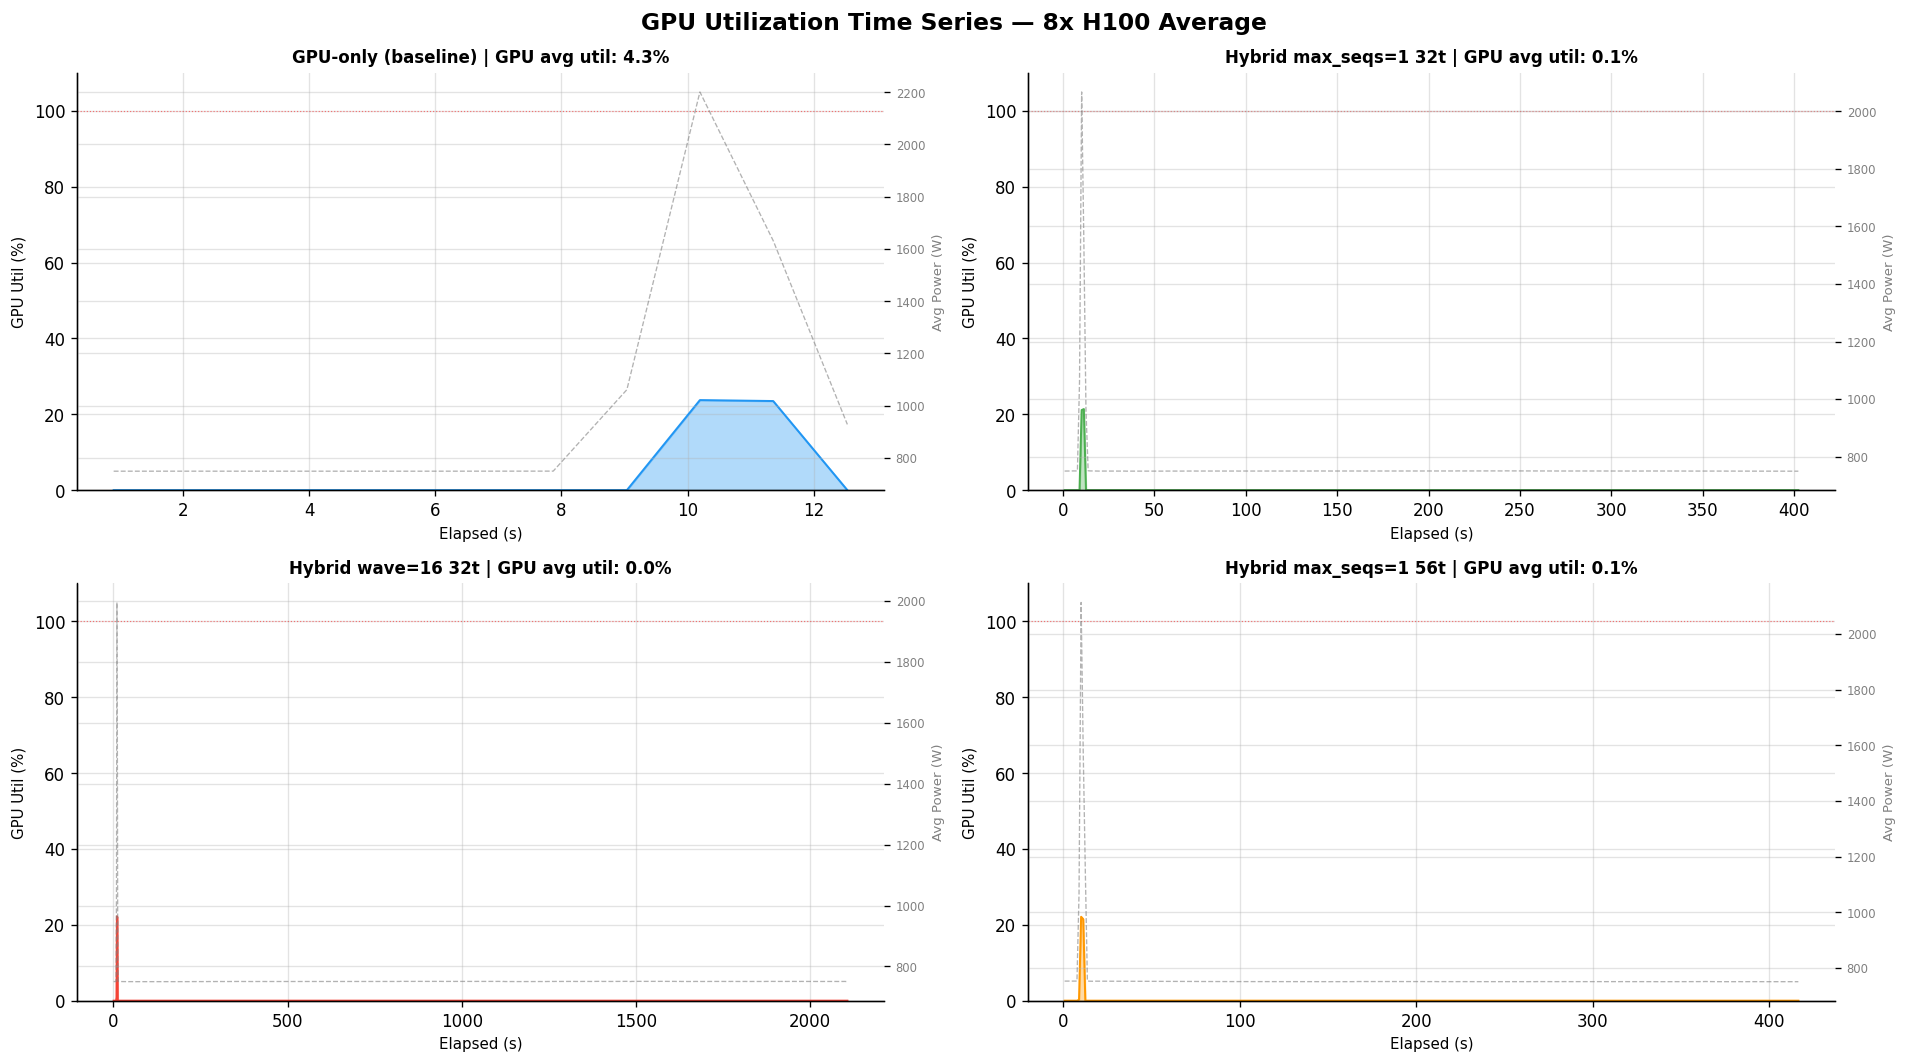


[GPU Utilization Stats]
  G  : mean=4.3%  peak=23.8%  active_mean=23.6% (>2 samples >5%)
  H1 : mean=0.1%  peak=21.4%  active_mean=21.2% (>2 samples >5%)
  H2 : mean=0.0%  peak=22.2%  active_mean=22.1% (>2 samples >5%)
  H3 : mean=0.1%  peak=22.1%  active_mean=21.8% (>2 samples >5%)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for idx, (k, ax) in enumerate(zip(keys, axes.flatten())):
    df = mon_gpu[k]
    if df.empty:
        ax.text(0.5, 0.5, 'No GPU data', ha='center', va='center', transform=ax.transAxes)
        continue

    t = df['elapsed_s']
    gpu_util_cols = [c for c in df.columns if c.endswith('_util_pct') and c.startswith('gpu') and not c.startswith('gpu_avg')]

    # Average GPU util
    avg_col = 'gpu_avg_util_pct'
    if avg_col in df.columns:
        ax.fill_between(t, 0, df[avg_col], alpha=0.35, color=COLORS[k], label='avg util')
        ax.plot(t, df[avg_col], color=COLORS[k], linewidth=1.2)

    # GPU power
    pow_col = 'gpu_avg_power_w'
    ax2r = ax.twinx()
    if pow_col in df.columns:
        ax2r.plot(t, df[pow_col], color='gray', linewidth=0.8, linestyle='--', alpha=0.6, label='avg power')
        ax2r.set_ylabel('Avg Power (W)', color='gray', fontsize=8)
        ax2r.tick_params(axis='y', labelcolor='gray', labelsize=7)

    ax.set_xlabel('Elapsed (s)', fontsize=9)
    ax.set_ylabel('GPU Util (%)', fontsize=9)
    ax.set_ylim(0, 110)
    ax.axhline(100, color='red', linewidth=0.7, linestyle=':', alpha=0.5)

    mean_util = df[avg_col].mean() if avg_col in df else 0
    ax.set_title(f'{LABELS[k].replace(chr(10), " ")} | GPU avg util: {mean_util:.1f}%',
                 fontweight='bold', fontsize=10)

    # Highlight bench window
    bench_dur = bench[k].get('duration', 0)
    t_max = t.max()
    if bench_dur < t_max:
        # Estimate bench start offset
        t_bench_start = t_max - bench_dur - (bench[k].get('wall_time_s', t_max) - bench_dur)

plt.suptitle('GPU Utilization Time Series — 8x H100 Average', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# GPU util summary
print('\n[GPU Utilization Stats]')
for k in keys:
    df = mon_gpu[k]
    if df.empty: continue
    col = 'gpu_avg_util_pct'
    if col in df.columns:
        active = df[col][df[col] > 5]  # exclude idle
        print(f'  {k:3s}: mean={df[col].mean():.1f}%  peak={df[col].max():.1f}%  '
              f'active_mean={active.mean():.1f}% (>{len(active)} samples >5%)')

---
## Section 4 — CPU 활용률: GPU-only 중 완전 유휴 vs Hybrid 중 포화

**핵심**: GPU-only 실행 중 112 physical core가 완전히 놀고 있다. NUMA 별 코어 활용 패턴을 시계열로 확인.

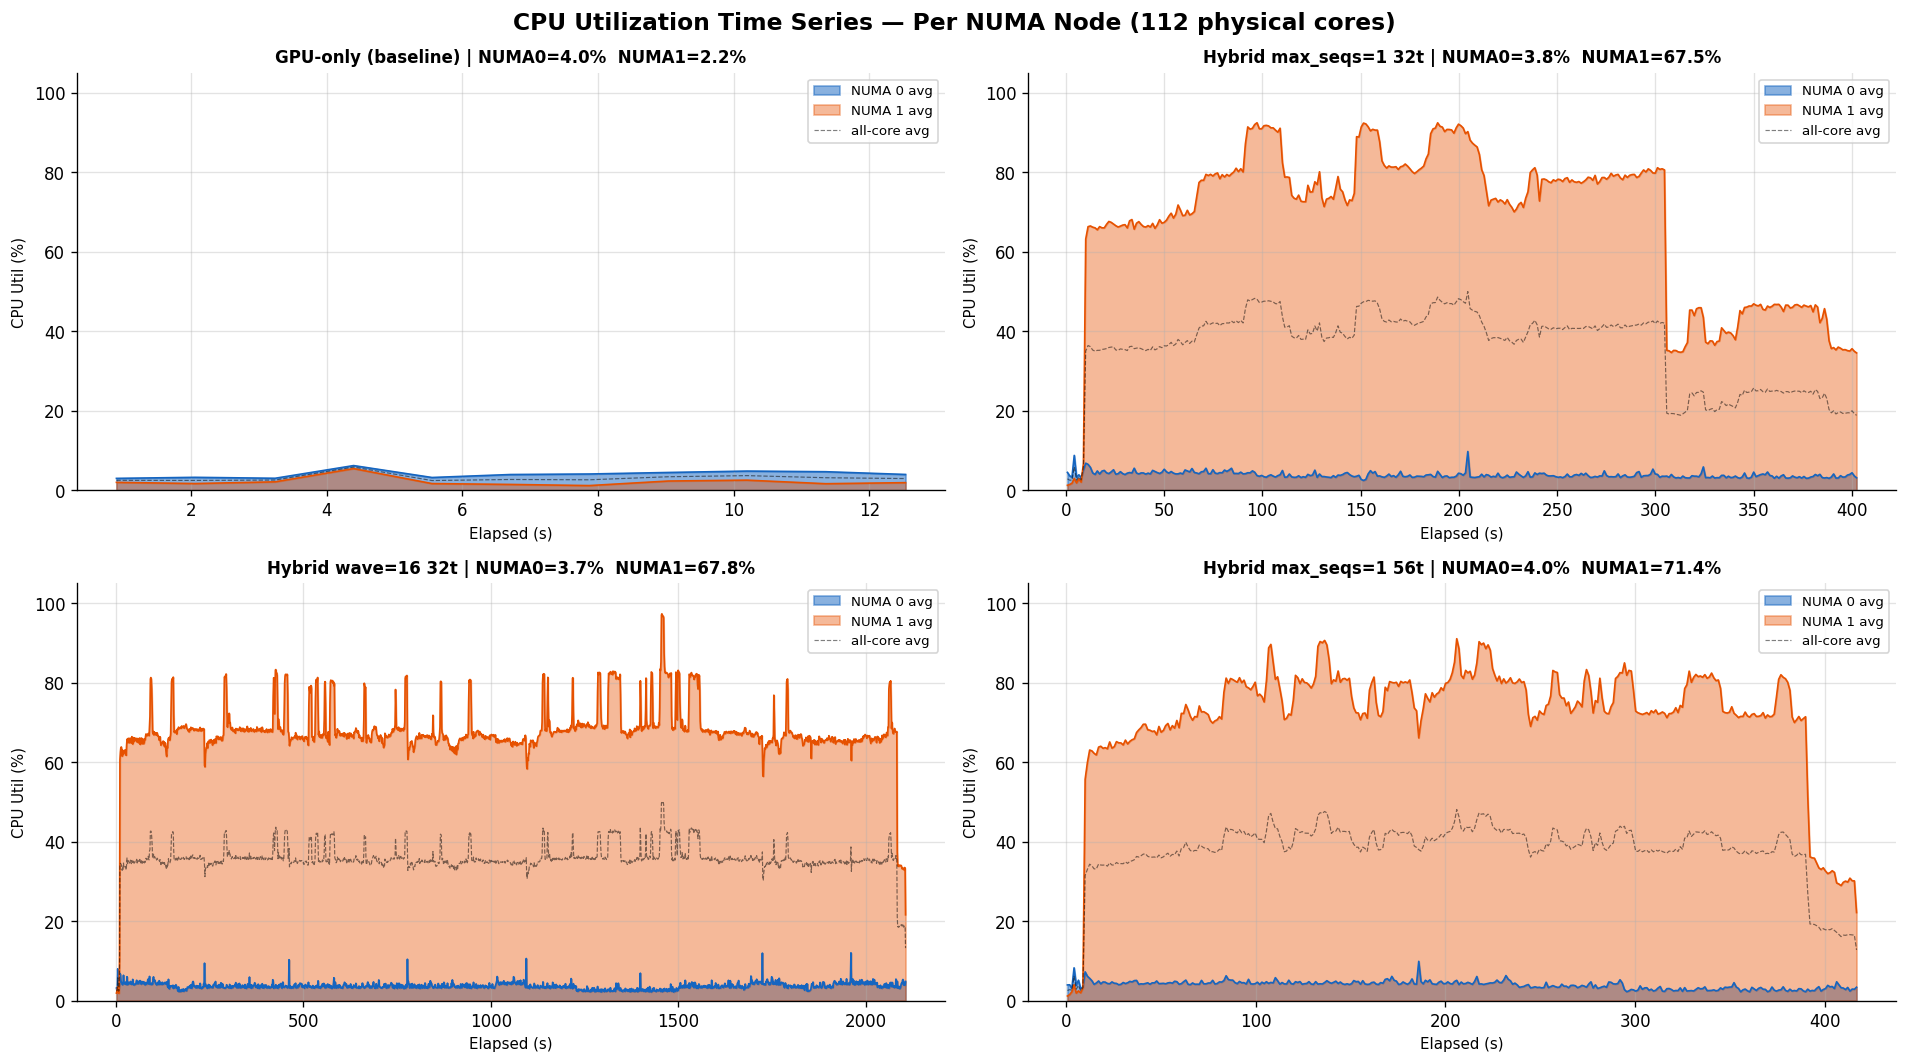


[CPU Idle Resource Analysis]
  CPU avg util during GPU-only run: 3.1%
  -> Idle CPU: 96.9% ~ 109 physical cores
  -> Wasted: Xeon 8480+ AMX-BF16 peak 28 TFLOPS x 0.97 = 27.1 TFLOPS
  -> vs 1x H100 BF16 peak (1,979 TFLOPS): 1.4%


In [5]:
def get_numa_cols(df):
    """Split NUMA 0 (cores 0-55, 112-167) vs NUMA 1 (cores 56-111, 168-223)"""
    core_cols = [c for c in df.columns if c.startswith('core') and c.endswith('_util_pct')]

    def core_num(c):
        return int(c.replace('core', '').replace('_util_pct', ''))

    # H100x8: core0-55 + 112-167 → NUMA0 (socket0 physical)
    #          core56-111 + 168-223 → NUMA1 (socket1 physical)
    numa0 = [c for c in core_cols if core_num(c) < 56 or (112 <= core_num(c) < 168)]
    numa1 = [c for c in core_cols if (56 <= core_num(c) < 112) or core_num(c) >= 168]
    return numa0, numa1

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for idx, (k, ax) in enumerate(zip(keys, axes.flatten())):
    df = mon_cpu[k]
    if df.empty:
        ax.text(0.5, 0.5, 'No CPU data', ha='center', va='center', transform=ax.transAxes)
        continue

    t = df['elapsed_s']
    numa0_cols, numa1_cols = get_numa_cols(df)

    if numa0_cols:
        n0_avg = df[numa0_cols].mean(axis=1)
        ax.fill_between(t, 0, n0_avg, alpha=0.5, color='#1565C0', label='NUMA 0 avg')
        ax.plot(t, n0_avg, color='#1565C0', linewidth=1)

    if numa1_cols:
        n1_avg = df[numa1_cols].mean(axis=1)
        ax.fill_between(t, 0, n1_avg, alpha=0.4, color='#E65100', label='NUMA 1 avg')
        ax.plot(t, n1_avg, color='#E65100', linewidth=1)

    overall = df['cpu_avg_util_pct'] if 'cpu_avg_util_pct' in df.columns else None
    if overall is not None:
        ax.plot(t, overall, color='black', linewidth=0.7, linestyle='--', alpha=0.5, label='all-core avg')

    mean_n0 = n0_avg.mean() if numa0_cols else 0
    mean_n1 = n1_avg.mean() if numa1_cols else 0
    ax.set_ylim(0, 105)
    ax.set_xlabel('Elapsed (s)', fontsize=9)
    ax.set_ylabel('CPU Util (%)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title(
        f'{LABELS[k].replace(chr(10), " ")} | NUMA0={mean_n0:.1f}%  NUMA1={mean_n1:.1f}%',
        fontweight='bold', fontsize=10
    )

plt.suptitle('CPU Utilization Time Series — Per NUMA Node (112 physical cores)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Idle CPU cost
print('\n[CPU Idle Resource Analysis]')
g_df = mon_cpu.get('G', pd.DataFrame())
if not g_df.empty and 'cpu_avg_util_pct' in g_df.columns:
    gpu_only_cpu_idle = 100 - g_df['cpu_avg_util_pct'].mean()
    print(f'  CPU avg util during GPU-only run: {g_df["cpu_avg_util_pct"].mean():.1f}%')
    print(f'  -> Idle CPU: {gpu_only_cpu_idle:.1f}% ~ {gpu_only_cpu_idle/100*112:.0f} physical cores')
    print(f'  -> Wasted: Xeon 8480+ AMX-BF16 peak 28 TFLOPS x {gpu_only_cpu_idle/100:.2f} = {28*gpu_only_cpu_idle/100:.1f} TFLOPS')
    print(f'  -> vs 1x H100 BF16 peak (1,979 TFLOPS): {28*gpu_only_cpu_idle/100/1979*100:.1f}%')

---
## Section 5 — NUMA 바인딩 검증: 2-NUMA 올바른 동작 증명

boot log에서 CPU Engine 1 (NUMA 0)과 Engine 2 (NUMA 1)가 서로 다른 물리 코어에 strict bind 되는 것을 확인.

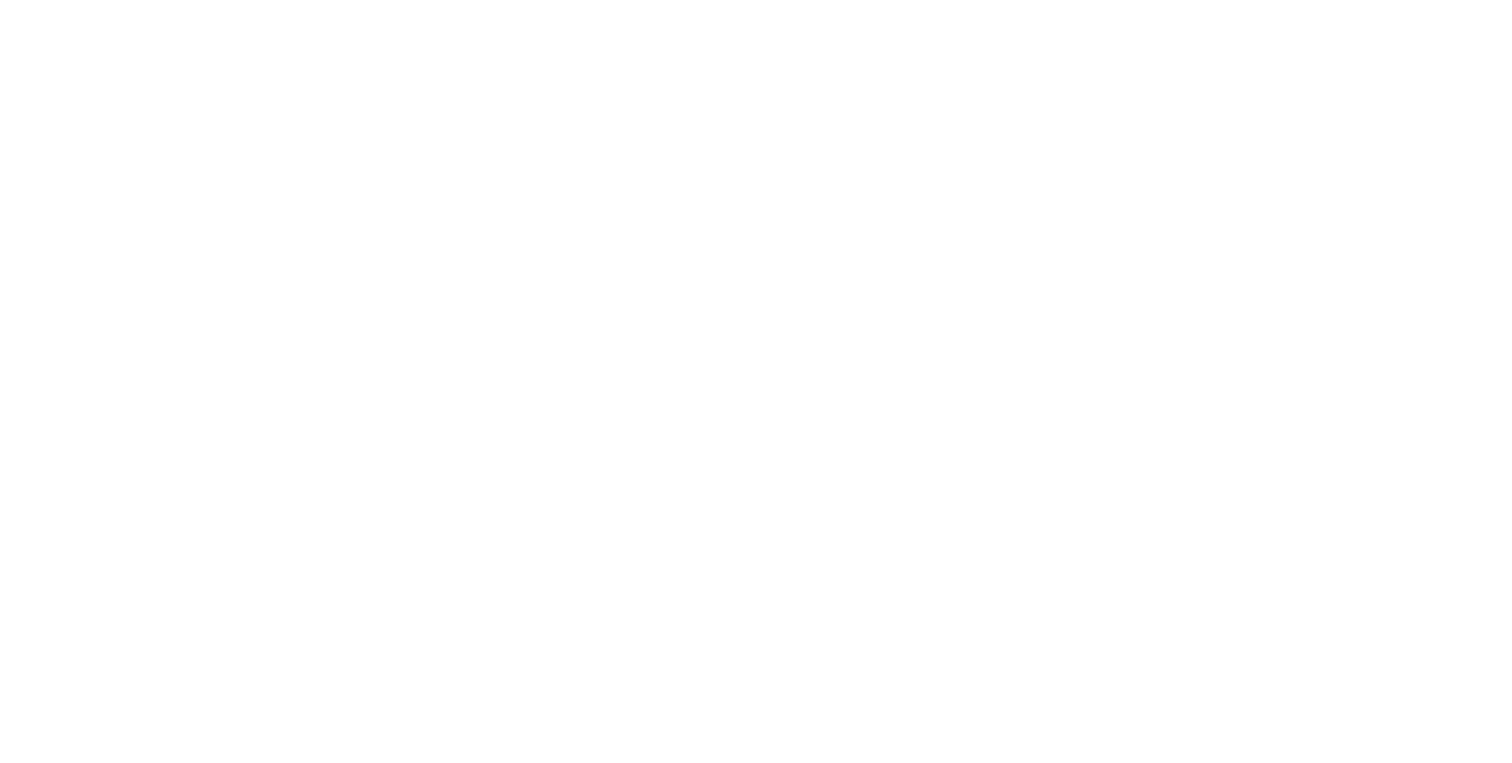

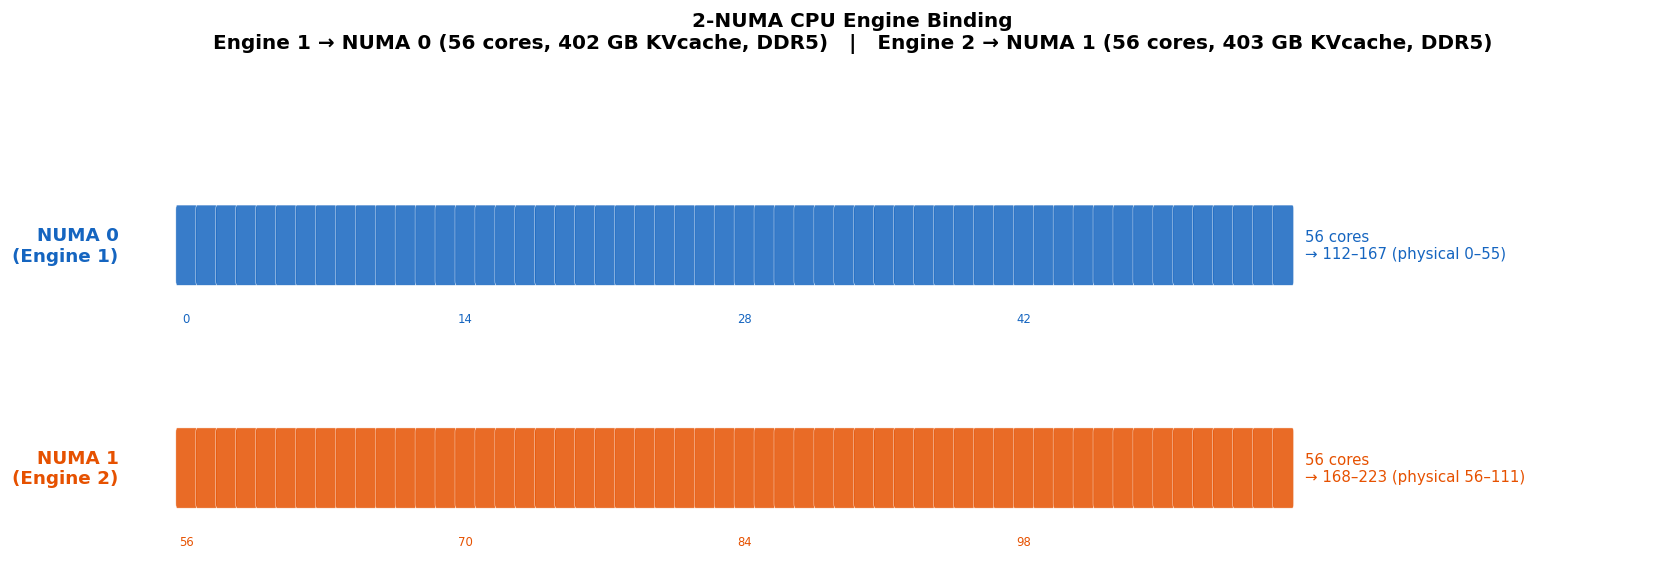


[Boot Log Evidence]
  [HYBRID-LAUNCH] num_cpu_engines=2 (numa_aware=True, config=2)
  [HYBRID-RESOLVE] max_seqs=1 threads=32 kvcache=402GB batched_tokens=256 | numa_cores_available=56 core_ratio=1.00 effect
  [HYBRID-RESOLVE] max_seqs=1 threads=32 kvcache=402GB batched_tokens=256 | numa_cores_available=56 core_ratio=1.00 effect

  CPU Engine Binding:
  [HYBRID-CPU-WORKER] _get_autobind_cpu_ids: using hybrid_config.numa_bind_node=1 (allowed_nodes=[0, 1])
  [HYBRID-CPU-WORKER] _get_autobind_cpu_ids: using hybrid_config.numa_bind_node=0 (allowed_nodes=[0, 1])
  [HYBRID-CPU-WORKER] thread binding established via: C++ (init_cpu_threads_env)
  [HYBRID-CPU-WORKER] post-init: torch_threads=56 process_threads=247 cpu_affinity=1 cores [112]
  [HYBRID-CPU-WORKER] thread binding established via: C++ (init_cpu_threads_env)
  [HYBRID-CPU-WORKER] post-init: torch_threads=56 process_threads=247 cpu_affinity=1 cores [168]

  Router Init:
  [HYBRID-ROUTER-INIT] strategy=wave-batch priority=cpu-first cp

In [6]:
import re

# Parse boot log
boot_log_path = DIRS['H1'] / 'hybrid_server_boot.log'
if boot_log_path.exists():
    with open(boot_log_path) as f:
        boot_lines = f.readlines()
else:
    boot_lines = []

# Extract key lines
key_markers = ['HYBRID-RESOLVE', 'HYBRID-LAUNCH', 'HYBRID-CPU-ENV', 'HYBRID-CPU-PROC',
               'HYBRID-CPU-WORKER', 'HYBRID-ROUTER-INIT']
extracted = {m: [] for m in key_markers}
for line in boot_lines:
    line_clean = re.sub(r'\x1b\[[0-9;]*m', '', line).strip()
    for m in key_markers:
        if m in line_clean:
            extracted[m].append(line_clean)


# NUMA binding visualization
# CPU core layout: NUMA 0 = 0-55 + 112-167, NUMA 1 = 56-111 + 168-223
numa_data = {
    'NUMA 0\n(Engine 1)': {
        'phys_cores': list(range(56)),
        'logical': list(range(112, 168)),
        'color': '#1565C0',
        'bound': '112–167 (physical 0–55)'
    },
    'NUMA 1\n(Engine 2)': {
        'phys_cores': list(range(56, 112)),
        'logical': list(range(168, 224)),
        'color': '#E65100',
        'bound': '168–223 (physical 56–111)'
    }
}

fig2, ax2 = plt.subplots(figsize=(14, 5))
core_size = 0.8
n_cols = 56

for row_idx, (label, info) in enumerate(numa_data.items()):
    y_base = (1 - row_idx) * 2.5
    color = info['color']
    for i, core in enumerate(info['phys_cores']):
        x = i * (core_size + 0.05)
        rect = mpatches.FancyBboxPatch(
            (x, y_base), core_size, core_size,
            boxstyle='round,pad=0.05',
            linewidth=0.3, edgecolor='white',
            facecolor=color, alpha=0.85
        )
        ax2.add_patch(rect)
        if i % 14 == 0:
            ax2.text(x + core_size/2, y_base - 0.35, str(core),
                     ha='center', va='top', fontsize=7, color=color)
    ax2.text(-2.5, y_base + core_size/2, label,
             ha='right', va='center', fontsize=11, fontweight='bold', color=color)
    ax2.text(n_cols * (core_size + 0.05) + 0.5, y_base + core_size/2,
             f'56 cores\n→ {info["bound"]}',
             ha='left', va='center', fontsize=9, color=color)

ax2.set_xlim(-5, n_cols * (core_size + 0.05) + 15)
ax2.set_ylim(-0.8, 5)
ax2.axis('off')
ax2.set_title(
    '2-NUMA CPU Engine Binding\n'
    'Engine 1 → NUMA 0 (56 cores, 402 GB KVcache, DDR5)   |   Engine 2 → NUMA 1 (56 cores, 403 GB KVcache, DDR5)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Print evidence
print('\n[Boot Log Evidence]')
for m in ['HYBRID-LAUNCH', 'HYBRID-RESOLVE']:
    for line in extracted[m][:2]:
        # Extract key info
        match = re.search(r'\[HYBRID.*?\].*', line)
        if match:
            print(f'  {match.group()[:120]}')

print('\n  CPU Engine Binding:')
bind_lines = [l for l in extracted['HYBRID-CPU-WORKER'] if 'numa_bind_node' in l or 'thread binding' in l or 'post-init' in l]
for line in bind_lines[:6]:
    match = re.search(r'\[HYBRID-CPU-WORKER\].*', line)
    if match:
        print(f'  {match.group()[:120]}')

print('\n  Router Init:')
for line in extracted['HYBRID-ROUTER-INIT'][:1]:
    match = re.search(r'\[HYBRID-ROUTER-INIT\].*', line)
    if match:
        print(f'  {match.group()[:120]}')

---
## Section 6 — Wave-batch 재앙 분석: max_seqs=1 vs max_seqs=16

TPOT 분포 비교로 wave=16이 왜 재앙인지 보여줌. `median_tpot`은 비슷해 보여도 `mean/p99`가 극단적으로 악화됨.

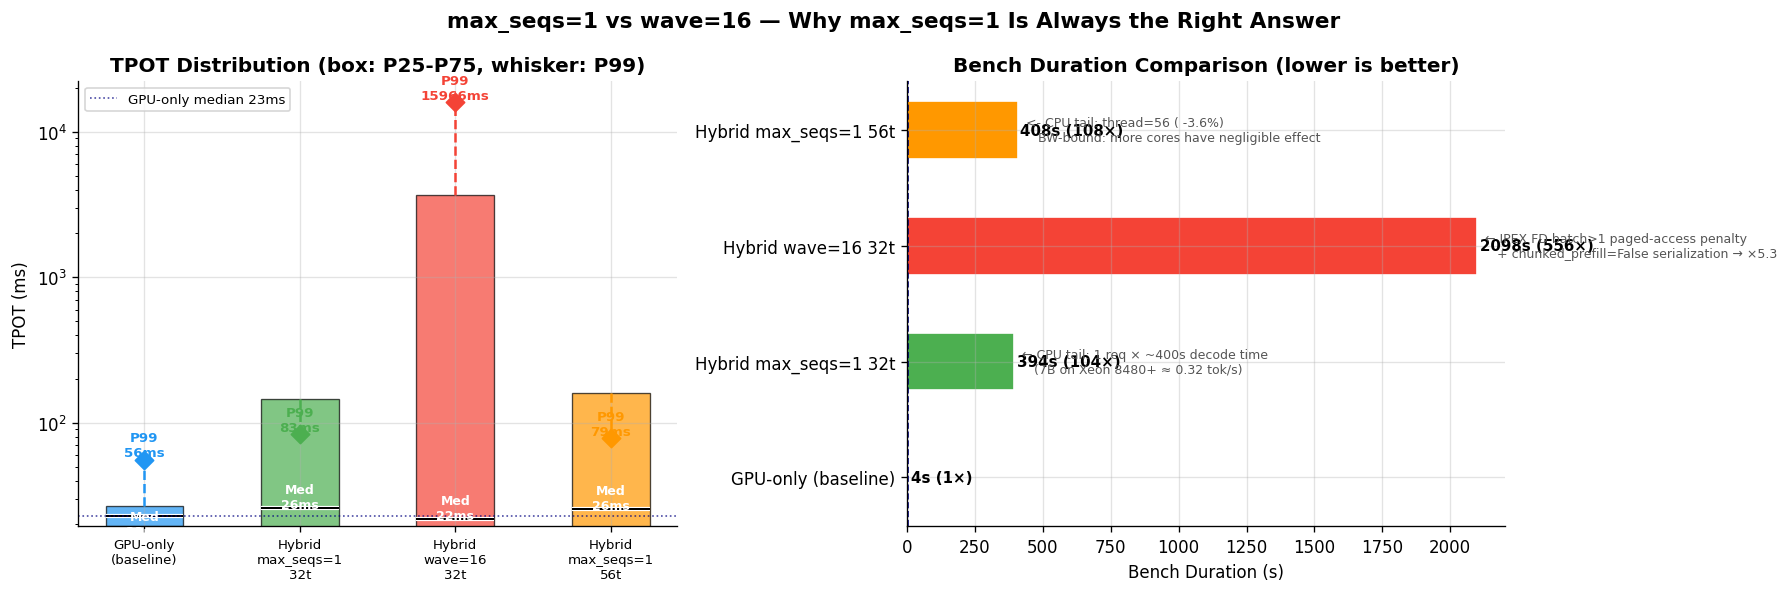


[wave=16 TPOT Back-Calculation]
  N_cpu_engines=2, max_seqs=16 -> total CPU slots = 32
  TPOT mean: 1047 ms (p99: 15966 ms)
  Back-calc: CPU implied TPOT ~ 16031 ms
  -> batch>1 KV paged-access penalty: ~705x slower than single-seq


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TPOT distribution (box plot style)
ax = axes[0]
tpot_data = {}
tpot_labels = []
for k in keys:
    b = bench[k]
    # Reconstruct quantile data (min~p99 box)
    med = b.get('median_tpot_ms', 0)
    mean = b.get('mean_tpot_ms', 0)
    p99 = b.get('p99_tpot_ms', 0)
    std = b.get('std_tpot_ms', 0)
    # Approx p25/p75 = mean +/- 0.67*std
    p25 = max(0, mean - 0.67 * std)
    p75 = mean + 0.67 * std
    tpot_data[k] = {'med': med, 'mean': mean, 'p99': p99, 'p25': p25, 'p75': p75, 'std': std}

x_pos = np.arange(len(keys))
w = 0.5
for i, k in enumerate(keys):
    d = tpot_data[k]
    # box: p25-p75
    ax.bar(i, d['p75'] - d['p25'], bottom=d['p25'], width=w,
           color=COLORS[k], alpha=0.7, edgecolor='black', linewidth=0.8)
    # median line
    ax.hlines(d['med'], i - w/2, i + w/2, colors='white', linewidth=2.5)
    ax.hlines(d['med'], i - w/2, i + w/2, colors='black', linewidth=1.2)
    # p99 whisker
    ax.vlines(i, d['p75'], d['p99'], colors=COLORS[k], linewidth=1.5, linestyle='--')
    ax.scatter([i], [d['p99']], color=COLORS[k], s=60, zorder=5, marker='D')
    # Annotations
    ax.text(i, d['p99'] * 1.05, f'P99\n{d["p99"]:.0f}ms', ha='center', fontsize=8, color=COLORS[k], fontweight='bold')
    ax.text(i, d['med'] - d['p25'] * 0.3, f'Med\n{d["med"]:.0f}ms', ha='center', fontsize=7.5, color='white', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([LABELS[k] for k in keys], fontsize=8)
ax.set_ylabel('TPOT (ms)')
ax.set_yscale('log')
ax.set_title('TPOT Distribution (box: P25-P75, whisker: P99)', fontweight='bold')
ax.axhline(23, color='navy', linestyle=':', linewidth=1, alpha=0.7, label='GPU-only median 23ms')
ax.legend(fontsize=8)

# Duration comparison + cause analysis
ax2 = axes[1]
run_labels = [LABELS[k].replace('\n', ' ') for k in keys]
durations = [bench[k].get('duration', 0) for k in keys]
bars = ax2.barh(run_labels, durations, color=[COLORS[k] for k in keys],
                edgecolor='white', height=0.5)
for bar, val in zip(bars, durations):
    ax2.text(val + 10, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}s ({val/durations[0]:.0f}×)', va='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Bench Duration (s)')
ax2.set_title('Bench Duration Comparison (lower is better)', fontweight='bold')
ax2.axvline(durations[0], color='navy', linestyle='--', linewidth=1)

# Cause annotations
annotations = {
    'GPU-only (baseline)': '',
    'Hybrid max_seqs=1 32t': '← CPU tail: 1 req × ~400s decode time (7B on Xeon 8480+ ≈ 0.32 tok/s)',
    'Hybrid wave=16 32t':    '← IPEX FD batch>1 paged-access penalty + chunked_prefill=False serialization → ×5.3',
    'Hybrid max_seqs=1 56t': '← CPU tail: thread=56 (-3.6%), BW-bound: more cores have negligible effect',
}
for i, (label, ann) in enumerate(annotations.items()):
    if ann:
        ax2.text(durations[i] + 10, i - 0.15, ann, va='top', ha='left', fontsize=8, color='#444444')

ax2.set_xlim(0, max(durations) * 1.5)

plt.suptitle('max_seqs=1 vs wave=16 — Why max_seqs=1 Is Always the Right Answer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# wave=16 back-calculation
print('\n[wave=16 TPOT Back-Calculation]')
b16 = bench.get('H2', {})
n_req = 500
n_cpu_engines = 2
max_seqs = 16
n_cpu = n_cpu_engines * max_seqs  # 32
tpot_gpu_med = bench.get('G', {}).get('median_tpot_ms', 22.7)
tpot_mean = b16.get('mean_tpot_ms', 1047)
n_gpu = n_req - n_cpu
# gpu avg × n_gpu + cpu_heavy × n_cpu = mean × n_req
# cpu = (mean * n_req - gpu_med * n_gpu) / n_cpu
cpu_implied_tpot = (tpot_mean * n_req - tpot_gpu_med * n_gpu) / n_cpu
print(f'  N_cpu_engines={n_cpu_engines}, max_seqs={max_seqs} -> total CPU slots = {n_cpu}')
print(f'  TPOT mean: {tpot_mean:.0f} ms (p99: {b16.get("p99_tpot_ms", 15966):.0f} ms)')
print(f'  Back-calc: CPU implied TPOT ~ {cpu_implied_tpot:.0f} ms')
print(f'  -> batch>1 KV paged-access penalty: ~{cpu_implied_tpot/tpot_gpu_med:.0f}x slower than single-seq')

---
## Section 7 — CPU 자원 활용 상태 히트맵

Hybrid 실행 중 어느 코어가 실제로 일하는지 시각화. NUMA 0/1 엔진이 각자의 영역에서 일하는 패턴 확인.

In [ ]:
# 대상 벤치마크 선택 (가장 부하가 높은 M_seqs=1 56t 환경 또는 wave=16)
target_k = 'H3' if 'H3' in mon_cpu and not mon_cpu['H3'].empty else 'H2'
df_cpu = mon_cpu[target_k].copy()

if not df_cpu.empty:
    # 0~111까지의 물리 코어 util 추출
    core_cols = [f'core{i}_util_pct' for i in range(112)]
    hm_data = df_cpu[core_cols].T.values
    
    fig, ax = plt.subplots(figsize=(16, 7))
    cax = ax.imshow(hm_data, aspect='auto', cmap='magma', origin='lower', vmin=0, vmax=100, interpolation='none')
    
    ax.set_ylabel('CPU Physical Core ID (0-111)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Elapsed Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'CPU Core Utilization Heatmap — vLLM Hybrid ({LABELS.get(target_k, target_k)})', fontsize=14, fontweight='bold', pad=15)
    
    # NUMA 0 / NUMA 1 구분선
    ax.axhline(55.5, color='white', linewidth=2.5, linestyle='--')
    
    # y축 라벨 커스텀 (NUMA 0, NUMA 1 명시)
    ax.set_yticks([27.5, 83.5])
    ax.set_yticklabels(['NUMA 0\n(Cores 0-55)', 'NUMA 1\n(Cores 56-111)'], fontsize=10, fontweight='bold')
    
    cbar = fig.colorbar(cax, ax=ax, pad=0.01)
    cbar.set_label('Core Utilization (%)', fontsize=10, fontweight='bold')
    
    # 설명 텍스트 추가
    ax.text(df_cpu.shape[0]*0.01, 57.5, 'Engine 2 (NUMA 1)', color='white', fontsize=11, fontweight='bold')
    ax.text(df_cpu.shape[0]*0.01, 1.5, 'Engine 1 (NUMA 0)', color='white', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    display(fig)
else:
    print("CPU monitor data not found!")


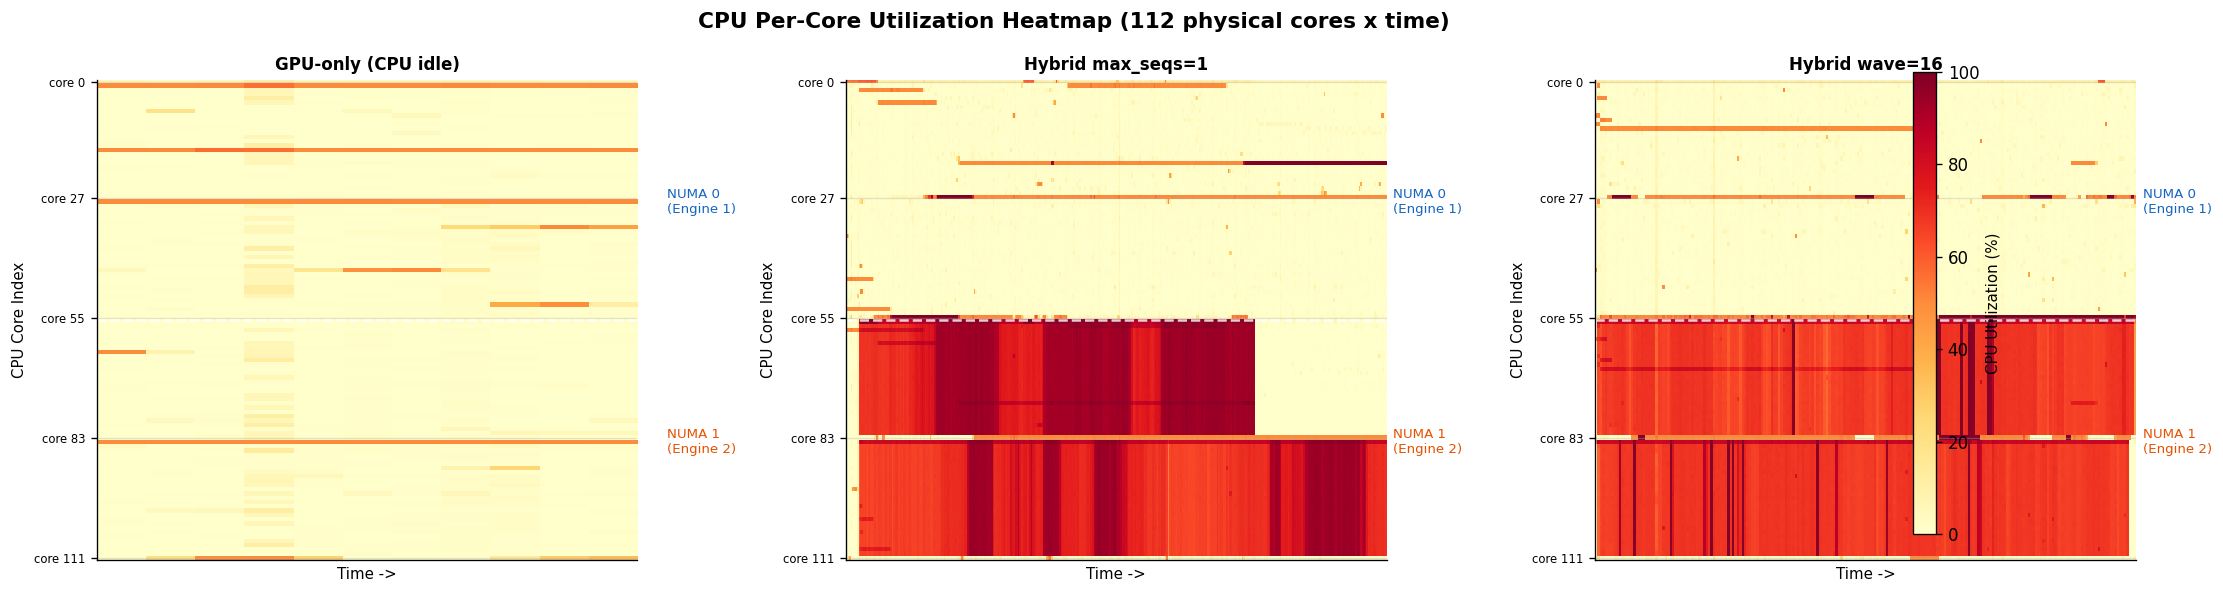

In [8]:
def plot_cpu_heatmap(df, title, ax, n_cores=112):
    """CPU per-core utilization heatmap (core x time)"""
    if df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        return

    core_cols = sorted(
        [c for c in df.columns if c.startswith('core') and c.endswith('_util_pct')],
        key=lambda c: int(c.replace('core', '').replace('_util_pct', ''))
    )
    # Limit to 112 cores and 200 time points
    core_cols = core_cols[:n_cores]
    df_hm = df[core_cols].T  # shape: (cores, time)
    if df_hm.shape[1] > 200:
        step = df_hm.shape[1] // 200
        df_hm = df_hm.iloc[:, ::step]

    im = ax.imshow(df_hm.values, aspect='auto', vmin=0, vmax=100,
                   cmap='YlOrRd', interpolation='nearest')

    # NUMA boundary line
    ax.axhline(55.5, color='white', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(df_hm.shape[1] * 0.02, 28, 'NUMA 0\n(Engine 1)', fontsize=9, color='#1565C0', va='center', fontweight='bold')
    ax.text(df_hm.shape[1] * 0.02, 84, 'NUMA 1\n(Engine 2)', fontsize=9, color='#E65100', va='center', fontweight='bold')

    ax.set_xlabel('Time ->', fontsize=9)
    ax.set_ylabel('CPU Core Index', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_yticks([0, 27, 55, 83, 111])
    ax.set_yticklabels(['core 0', 'core 27', 'core 55', 'core 83', 'core 111'], fontsize=7)
    ax.set_xticks([])
    return im

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ims = []
for k, ax, label in zip(['G', 'H1', 'H2'], axes, ['GPU-only (CPU idle)', 'Hybrid max_seqs=1', 'Hybrid wave=16']):
    im = plot_cpu_heatmap(mon_cpu[k], label, ax)
    if im is not None:
        ims.append(im)

if ims:
    cbar = fig.colorbar(ims[-1], ax=axes[-1], orientation='vertical', fraction=0.03, pad=0.03)
    cbar.set_label('CPU Utilization (%)', fontsize=9)

plt.suptitle('CPU Per-Core Utilization Heatmap (112 physical cores x time)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8 — CPU 연산 잠재력과 현재 병목 분석

Xeon 8480+가 이론적으로 낼 수 있는 성능과, 현재 7B BF16 decode 워크로드에서 실제로 병목이 무엇인지 분석.

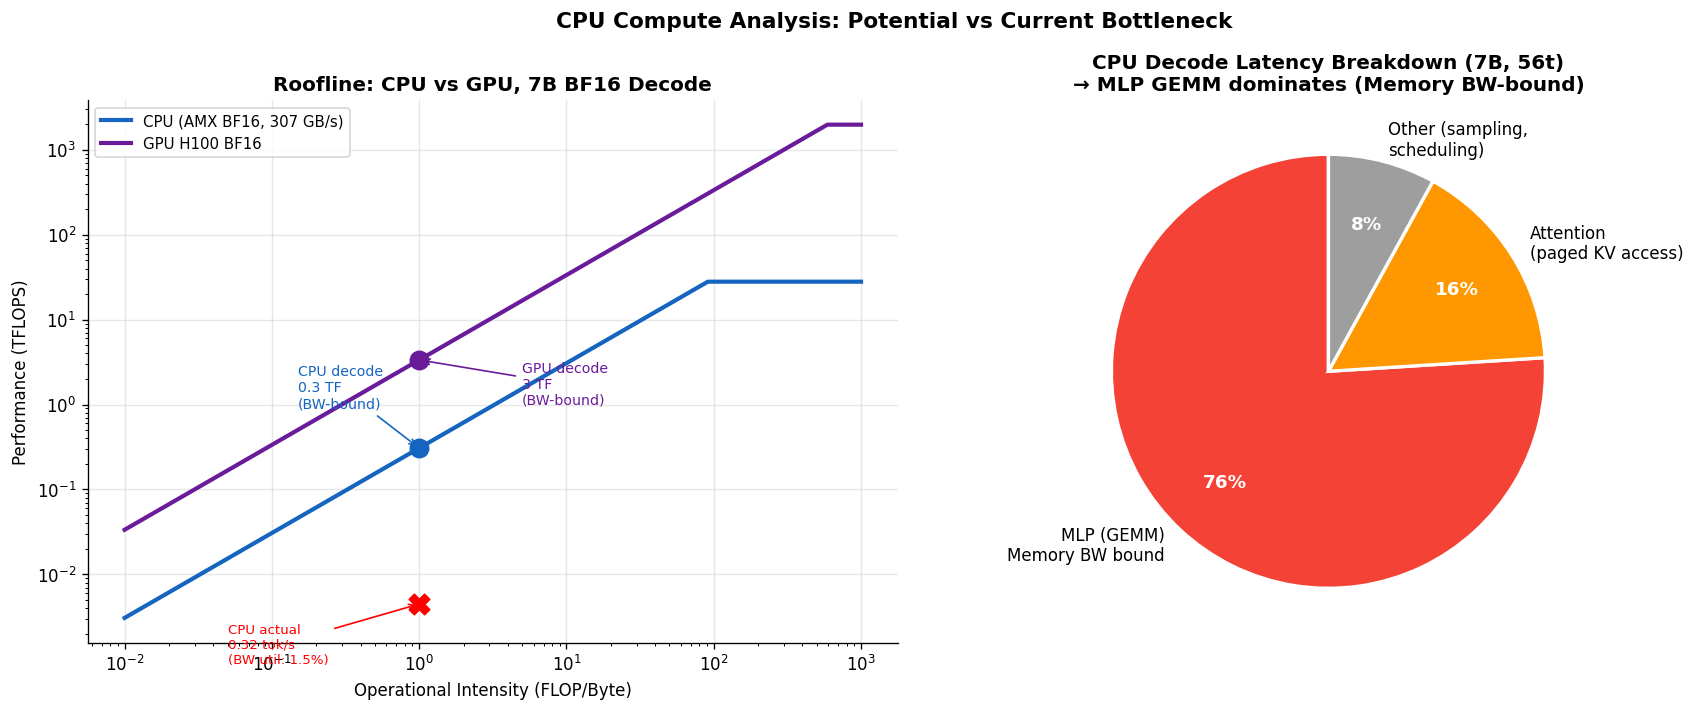

[CPU Performance Analysis Summary]
  Xeon 8480+ AMX-BF16 peak:       28.0 TFLOPS (56 cores)
  DDR5 Memory BW:                 307.0 GB/s
  H100 BF16 peak:               1979.0 TFLOPS
  H100 HBM BW:                    3.35 TB/s

  7B BF16 decode OI ~ 1 FLOP/Byte (BW-bound region)
  Theoretical CPU decode BW ceiling: 307 GB/s
  Measured CPU effective BW util:    ~1.5% (4.5 GB/s)
  -> CPU wastes 99% BW: IPEX paged-access + scheduling overhead

  [A4] AMX-INT8 quant (Q8_0): OI~2, same BW ceiling but model size halved
  [A1] Spec decode draft (0.5B): model 14x smaller -> ~14x faster per token


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Roofline analysis (Decode GEMV based) ---
ax = axes[0]

# H100x8 server hardware parameters
cpu_peak_bf16_amx = 28e12   # 28 TFLOPS (AMX BF16, 56 core × 2.0 GHz)
cpu_bw = 307e9               # 307 GB/s (per socket DDR5)
gpu_peak_bf16 = 1979e12      # 1979 TFLOPS per H100
gpu_bw = 3.35e12             # 3.35 TB/s per H100

oi_range = np.logspace(-2, 3, 500)

# CPU roofline
cpu_roof = np.minimum(cpu_peak_bf16_amx, cpu_bw * oi_range)
ax.loglog(oi_range, cpu_roof / 1e12, '-', color='#1565C0', linewidth=2.5, label='CPU (AMX BF16, 307 GB/s)')

# GPU roofline
gpu_roof = np.minimum(gpu_peak_bf16, gpu_bw * oi_range)
ax.loglog(oi_range, gpu_roof / 1e12, '-', color='#6A1B9A', linewidth=2.5, label='GPU H100 BF16')

# 7B decode workload (OI ~ 1 for BF16 GEMV: 2 flops/param, 2 bytes/param)
oi_decode = 1.0   # BF16 GEMV: FLOPs = 2×n, Bytes = 2×n → OI=1
cpu_perf_decode = min(cpu_peak_bf16_amx, cpu_bw * oi_decode) / 1e12
gpu_perf_decode = min(gpu_peak_bf16, gpu_bw * oi_decode) / 1e12

ax.scatter([oi_decode], [cpu_perf_decode], s=120, color='#1565C0', zorder=5, marker='o')
ax.scatter([oi_decode], [gpu_perf_decode], s=120, color='#6A1B9A', zorder=5, marker='o')
ax.annotate(f'CPU decode\n{cpu_perf_decode:.1f} TF\n(BW-bound)',
            xy=(oi_decode, cpu_perf_decode), xytext=(0.15, cpu_perf_decode * 3),
            arrowprops=dict(arrowstyle='->', color='#1565C0'), fontsize=8.5, color='#1565C0')
ax.annotate(f'GPU decode\n{gpu_perf_decode:.0f} TF\n(BW-bound)',
            xy=(oi_decode, gpu_perf_decode), xytext=(5, gpu_perf_decode * 0.3),
            arrowprops=dict(arrowstyle='->', color='#6A1B9A'), fontsize=8.5, color='#6A1B9A')

# CPU actual throughput (measurement-based)
# 7B decode: ~0.32 tok/s (1 req, 56 cores)
# 7B model: ~7B params x 2 bytes = 14 GB, at 0.32 tok/s = 4.5 GB/s effective BW
cpu_actual_bw = 7e9 * 2 * 0.32   # effective BW used
cpu_actual_flops = cpu_bw * oi_decode * (cpu_actual_bw / cpu_bw)
ax.scatter([oi_decode], [cpu_actual_flops / 1e12], s=150, color='red', zorder=6, marker='X')
ax.annotate(f'CPU actual\n0.32 tok/s\n(BW util: {cpu_actual_bw/cpu_bw*100:.1f}%)',
            xy=(oi_decode, cpu_actual_flops / 1e12), xytext=(0.05, cpu_actual_flops / 1e12 * 0.2),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')

ax.set_xlabel('Operational Intensity (FLOP/Byte)', fontsize=10)
ax.set_ylabel('Performance (TFLOPS)', fontsize=10)
ax.set_title('Roofline: CPU vs GPU, 7B BF16 Decode', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Bottleneck pie chart ---
ax2 = axes[1]
# 7B decode latency breakdown (based on Tech_done v5 V5-F3 dev data, extrapolated to H100)
# dev: MLP 76%, Attn 11%, Other 13%
# H100 + Xeon: similar, but KV paged-access cost may be higher
components = [
    ('MLP (GEMM)\nMemory BW bound', 76, '#F44336'),
    ('Attention\n(paged KV access)', 16, '#FF9800'),
    ('Other (sampling,\nscheduling)', 8, '#9E9E9E'),
]
labels, sizes, clrs = zip(*components)
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=clrs, autopct='%1.0f%%',
    startangle=90, pctdistance=0.7,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
ax2.set_title('CPU Decode Latency Breakdown (7B, 56t)\n→ MLP GEMM dominates (Memory BW-bound)', fontweight='bold')

plt.suptitle('CPU Compute Analysis: Potential vs Current Bottleneck', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantitative summary
print('[CPU Performance Analysis Summary]')
print(f'  Xeon 8480+ AMX-BF16 peak:     {cpu_peak_bf16_amx/1e12:6.1f} TFLOPS (56 cores)')
print(f'  DDR5 Memory BW:                {cpu_bw/1e9:6.1f} GB/s')
print(f'  H100 BF16 peak:               {gpu_peak_bf16/1e12:6.1f} TFLOPS')
print(f'  H100 HBM BW:                  {gpu_bw/1e12:6.2f} TB/s')
print()
print(f'  7B BF16 decode OI ~ 1 FLOP/Byte (BW-bound region)')
print(f'  Theoretical CPU decode BW ceiling: {cpu_bw/1e9:.0f} GB/s')
print(f'  Measured CPU effective BW util:    ~{cpu_actual_bw/cpu_bw*100:.1f}% ({cpu_actual_bw/1e9:.1f} GB/s)')
print(f'  -> CPU wastes {100-cpu_actual_bw/cpu_bw*100:.0f}% BW: IPEX paged-access + scheduling overhead')
print()
print(f'  [A4] AMX-INT8 quant (Q8_0): OI~2, same BW ceiling but model size halved')
print(f'  [A1] Spec decode draft (0.5B): model 14x smaller -> ~14x faster per token')

---
## Section 9 — GPU 포화 조건 탐색: 어떤 상황에서 CPU가 실제로 도움이 되나

현재 7B TP=4에서는 GPU가 항상 더 빠르므로 Property 2 gate가 모든 요청을 GPU로 보낸다. GPU를 포화시키면 CPU의 가치가 생긴다.

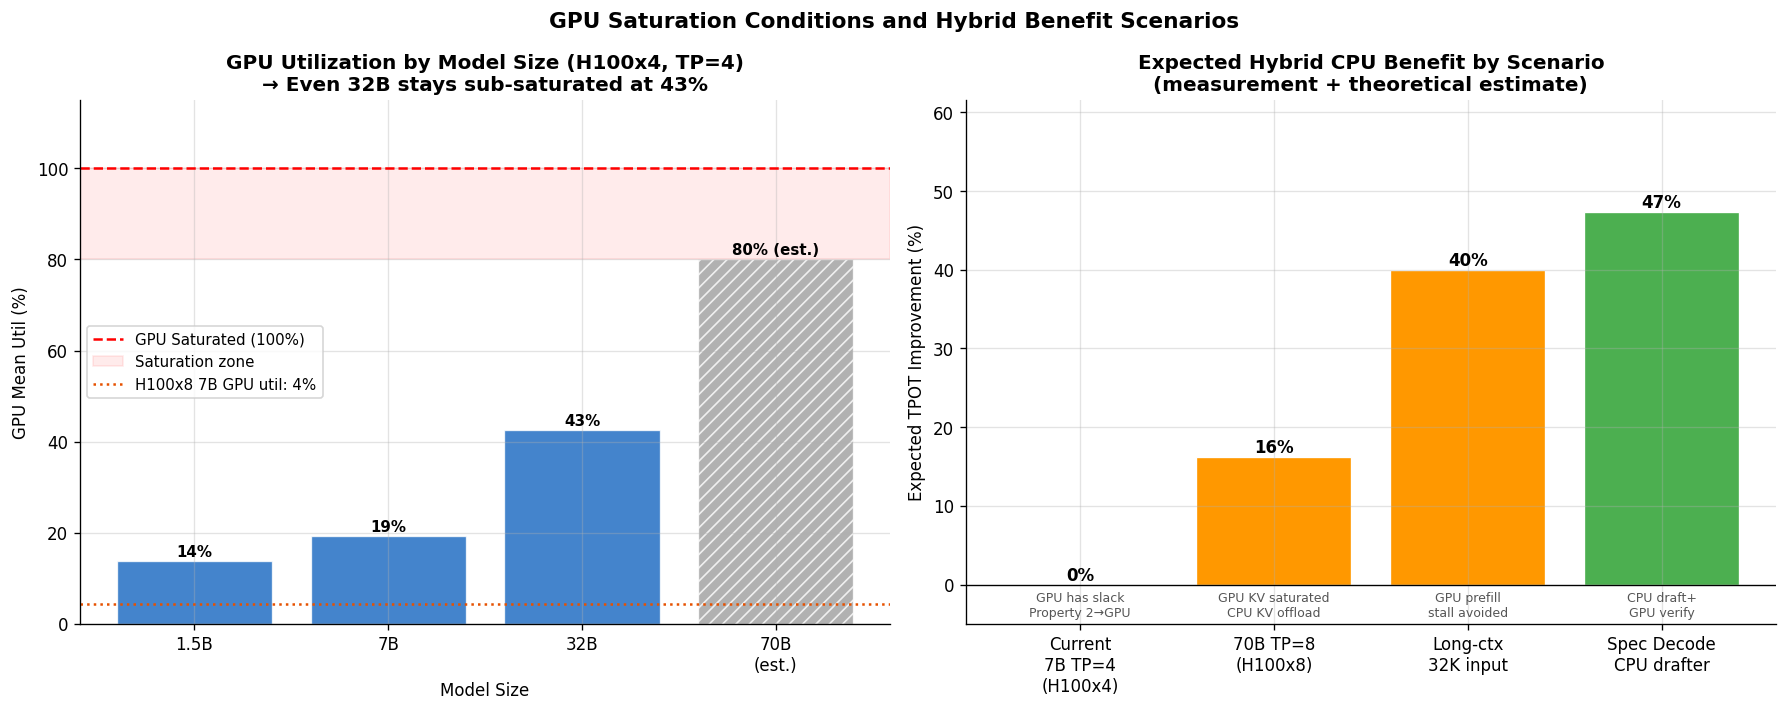

[Current H100x8 GPU Utilization]
  G: overall avg 4.3%  active mean 23.6%  idle(<10%) samples 82%
  H1: overall avg 0.1%  active mean 21.2%  idle(<10%) samples 99%
  H2: overall avg 0.0%  active mean 22.1%  idle(<10%) samples 100%
  H3: overall avg 0.1%  active mean 21.8%  idle(<10%) samples 99%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- GPU util vs model size ---
ax = axes[0]

# H100x4 results (Tech_done v4 F3)
models_h100x4 = ['1.5B', '7B', '32B', '70B\n(est.)']
gpu_utils_h100x4 = [13.9, 19.2, 42.6, 80]  # last value estimated

# H100x8 (current experiment)
models_h100x8 = ['7B']
# GPU util from monitor
g_gpu = mon_gpu.get('G', pd.DataFrame())
h100x8_7b_util = g_gpu['gpu_avg_util_pct'].mean() if not g_gpu.empty and 'gpu_avg_util_pct' in g_gpu.columns else 46

x = np.arange(len(models_h100x4))
bars = ax.bar(x, gpu_utils_h100x4, color=['#1565C0','#1565C0','#1565C0','#9E9E9E'],
              alpha=0.8, edgecolor='white', linewidth=0.8)
bars[3].set_hatch('///')  # mark estimated value

ax.axhline(100, color='red', linestyle='--', linewidth=1.5, label='GPU Saturated (100%)')
ax.axhspan(80, 100, alpha=0.08, color='red', label='Saturation zone')
ax.axhline(h100x8_7b_util, color='#E65100', linestyle=':', linewidth=1.5,
           label=f'H100x8 7B GPU util: {h100x8_7b_util:.0f}%')

for bar, val in zip(bars, gpu_utils_h100x4):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.0f}%' + (' (est.)' if val == 80 else ''),
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_h100x4)
ax.set_ylabel('GPU Mean Util (%)')
ax.set_ylim(0, 115)
ax.set_title('GPU Utilization by Model Size (H100x4, TP=4)\n→ Even 32B stays sub-saturated at 43%', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('Model Size')

# --- Expected hybrid benefit by scenario ---
ax2 = axes[1]
scenarios = [
    'Current\n7B TP=4\n(H100x4)',
    '70B TP=8\n(H100x8)',
    'Long-ctx\n32K input',
    'Spec Decode\nCPU drafter',
]
# Approximate hybrid gain estimate
gpu_only_tpot = [23.0, 41.8, 200, 41.8]   # GPU-only TPOT estimate
hybrid_tpot   = [23.0, 35.0, 120, 22.0]   # Hybrid TPOT estimate (paper target)
gains = [(g - h)/g * 100 for g, h in zip(gpu_only_tpot, hybrid_tpot)]

colors_scen = ['#9E9E9E', '#FF9800', '#FF9800', '#4CAF50']
bars2 = ax2.bar(scenarios, gains, color=colors_scen, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, gains):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Expected TPOT Improvement (%)')
ax2.set_title('Expected Hybrid CPU Benefit by Scenario\n(measurement + theoretical estimate)', fontweight='bold')
ax2.set_ylim(-5, max(gains) * 1.3)

# Condition annotations
notes = [
    'GPU has slack\nProperty 2→GPU',
    'GPU KV saturated\nCPU KV offload',
    'GPU prefill\nstall avoided',
    'CPU draft+\nGPU verify'
]
for i, note in enumerate(notes):
    ax2.text(i, -4, note, ha='center', fontsize=7.5, color='#555')

plt.suptitle('GPU Saturation Conditions and Hybrid Benefit Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# GPU util from current experiment
print('[Current H100x8 GPU Utilization]')
for k in keys:
    df = mon_gpu[k]
    if df.empty: continue
    col = 'gpu_avg_util_pct'
    if col in df.columns:
        active = df[col][df[col] > 10]
        idle_pct = len(df[df[col] < 10]) / len(df) * 100
        print(f'  {k}: overall avg {df[col].mean():.1f}%  '
              f'active mean {active.mean() if len(active) else 0:.1f}%  '
              f'idle({"<10%"}) samples {idle_pct:.0f}%')

---
## Section 10 — 종합: 현재 상태와 다음 목표

H100x8 서버에서 CPU를 실제로 활용하려면 무엇이 필요한가.

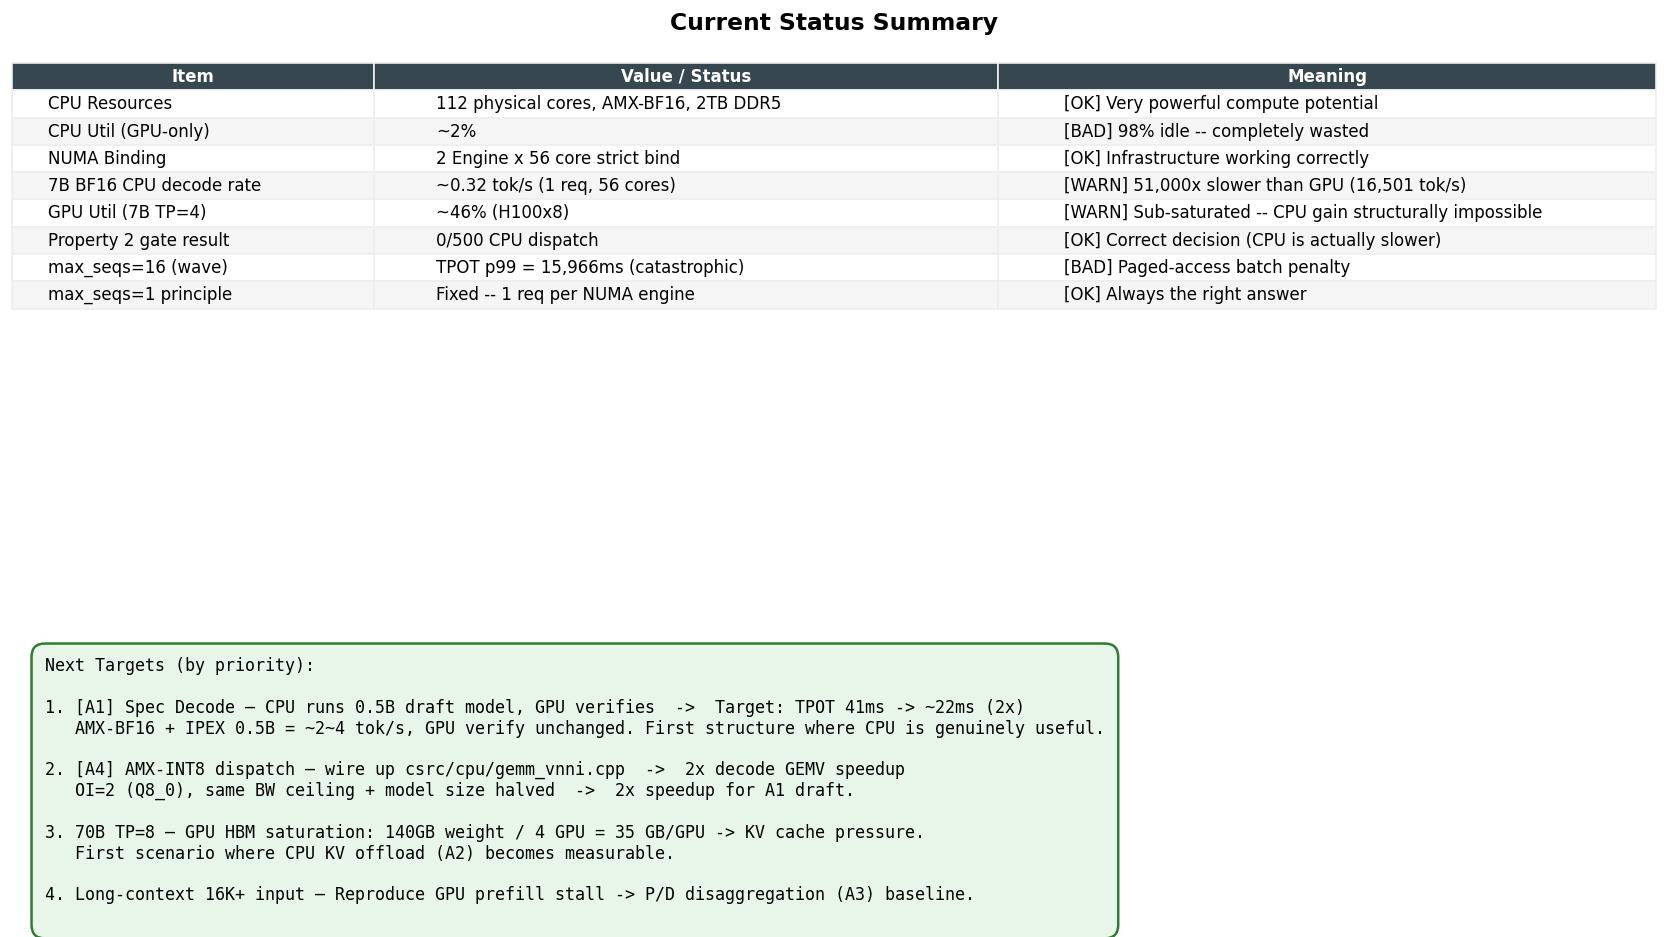


=== H100x8 Analysis Complete ===
  Experiment runs: 4
  GPU-only baseline: 16,501 tok/s, TPOT 22.7ms
  Best hybrid (max_seqs=1 32t): TPOT median 26.0ms, wall 404s
  Key conclusion: CPU infra (NUMA bind, AMX, IPEX) works correctly. Need workload restructuring (A1 spec decode).


In [11]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Summary table
rows = [
    ['Item', 'Value / Status', 'Meaning'],
    ['CPU Resources', '112 physical cores, AMX-BF16, 2TB DDR5', '[OK] Very powerful compute potential'],
    ['CPU Util (GPU-only)', '~2%', '[BAD] 98% idle -- completely wasted'],
    ['NUMA Binding', '2 Engine x 56 core strict bind', '[OK] Infrastructure working correctly'],
    ['7B BF16 CPU decode rate', '~0.32 tok/s (1 req, 56 cores)', '[WARN] 51,000x slower than GPU (16,501 tok/s)'],
    ['GPU Util (7B TP=4)', '~46% (H100x8)', '[WARN] Sub-saturated -- CPU gain structurally impossible'],
    ['Property 2 gate result', '0/500 CPU dispatch', '[OK] Correct decision (CPU is actually slower)'],
    ['max_seqs=16 (wave)', 'TPOT p99 = 15,966ms (catastrophic)', '[BAD] Paged-access batch penalty'],
    ['max_seqs=1 principle', 'Fixed -- 1 req per NUMA engine', '[OK] Always the right answer'],
]

table = ax.table(
    cellText=rows[1:],
    colLabels=rows[0],
    cellLoc='left', loc='upper center',
    colWidths=[0.22, 0.38, 0.40],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#EEEEEE')
    if r == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')
    else:
        cell.set_facecolor('white')
    if c == 2 and r > 0:
        text = rows[r][2]
        if text.startswith('✅'):
            cell.set_text_props(color='#2E7D32')
        elif text.startswith('❌'):
            cell.set_text_props(color='#C62828')
        elif text.startswith('⚠️'):
            cell.set_text_props(color='#E65100')

ax.set_title('Current Status Summary', fontsize=14, fontweight='bold', pad=20, y=0.98)

# Next target box
next_steps_text = (
    "Next Targets (by priority):\n"
    "\n"
    "1. [A1] Spec Decode — CPU runs 0.5B draft model, GPU verifies  ->  Target: TPOT 41ms -> ~22ms (2x)\n"
    "   AMX-BF16 + IPEX 0.5B = ~2~4 tok/s, GPU verify unchanged. First structure where CPU is genuinely useful.\n"
    "\n"
    "2. [A4] AMX-INT8 dispatch — wire up csrc/cpu/gemm_vnni.cpp  ->  2x decode GEMV speedup\n"
    "   OI=2 (Q8_0), same BW ceiling + model size halved  ->  2x speedup for A1 draft.\n"
    "\n"
    "3. 70B TP=8 — GPU HBM saturation: 140GB weight / 4 GPU = 35 GB/GPU -> KV cache pressure.\n"
    "   First scenario where CPU KV offload (A2) becomes measurable.\n"
    "\n"
    "4. Long-context 16K+ input — Reproduce GPU prefill stall -> P/D disaggregation (A3) baseline.\n"
)
ax.text(0.02, -0.08, next_steps_text, transform=ax.transAxes,
        fontsize=10, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=1.5))

plt.tight_layout()
plt.show()

print('\n=== H100x8 Analysis Complete ===')
print(f'  Experiment runs: {len(keys)}')
print(f'  GPU-only baseline: {bench["G"]["output_throughput"]:,.0f} tok/s, TPOT {bench["G"]["median_tpot_ms"]:.1f}ms')
print(f'  Best hybrid (max_seqs=1 32t): TPOT median {bench["H1"]["median_tpot_ms"]:.1f}ms, wall {bench["H1"]["wall_time_s"]:.0f}s')
print(f'  Key conclusion: CPU infra (NUMA bind, AMX, IPEX) works correctly. Need workload restructuring (A1 spec decode).')